In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ait.photonic_testing.photonic_testing import *
MODBUS_PORT='/dev/tty.usbserial-B003T6PZ'
LASER_ADDRESSES = {"1028": 5,
                   "1270": 6,
                   "yj1430": 4,
                   "hk1430": 3,
                   "1510": 1,
                   "2330": 2}

### Overview

See `ait/photonic_testing.py` for `Laser` and `LaserProperties` along with the specific limits of the individual laser diodes.


## Initialize all the diodes

Running this cell will create the `lasers` dictionary with a `Laser` for each laser.

In [2]:
names = tuple(LASER_ADDRESSES.keys())
lasers = {name: Laser(name, address=LASER_ADDRESSES[name], MODBUS_PORT=MODBUS_PORT) for name in names}

Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.


In [3]:
for l in lasers.values(): l.startup()

Programming limits for 1028, Maiman driver: S/N 8229...
Programming limits for 1270, Maiman driver: S/N 8228...
Programming limits for yj1430, Maiman driver: S/N 8222...
Programming limits for hk1430, Maiman driver: S/N 8227...
Programming limits for 1510, Maiman driver: S/N 8225...
Programming limits for 2330, Maiman driver: S/N 8226...


### Turn on a laser

In [4]:
lasers['2330'].set_current_as_percent(1, autooff=0)

Setting current to 120.0 mA... 
  done. Estimated output 2.95 mW @ 2330.445 nm.
Laser Name: '2330'
Operation started: True
Voltage: 3.1
Current (min-max): 120.00 (0.00-120.00
Current Set Calibration: 100.0
TEC Started: True
 TEC Temperature Setpoint: 27.7
 TEC Temperature: 30.77
 TEC Voltage: 1.3
 TEC Current Limit: 1.2
 TEC Current: 0.8
 TEC Error: False
 TEC Self-heat: False
LD Overcurrent: False
LD Overheat: False


Look at the status of one of them. It seems that the TEC status isn't polling well, but the temp changes.

In [4]:
lasers['2330'].status(verbose=False)

Laser Name: '2330'
Operation started: False
Voltage: 0.0
Current (min-max): 0.00 (0.00-120.00)
Current Set Calibration: 100.0
TEC Started: True
 TEC Temperature Setpoint: 29.0
 TEC Temperature: 29.09
 TEC Voltage: 0.1
 TEC Current Limit: 1.2
 TEC Current: 0.0
 TEC Error: False
 TEC Self-heat: False
LD Overcurrent: False
LD Overheat: False


In [34]:
lasers['2330'].tune_wavelength(1,2329*u.nm, maximum_power_shift=.1, autooff=0, apply=False)

Requested tuning 2329.810 nm to 2329.000 nm at 100.0±10.00% flux.
    TEC Temp: 18.25 deg_C (current 34.92 deg_C), resulting dl from nominal -0.810 nm.
    Drive current: 120.0 mA->120.0 mA, resulting dl 0.000 nm.
    Optical Power: 2.95 mW
    Laser power difference from request: 0.00 mW
    Wavelength difference from request: 0.000 nm
    Note drive accuracy: 0.028 nm


<Quantity 2330.9992 nm>

In [43]:
data = lasers['2330'].tune_and_monitor(1,2329*u.nm, duration_s=50, maximum_power_shift=.1, autooff=0, apply=True, cadence_hz=10)

Requested tuning 2329.810 nm to 2329.000 nm at 100.0±10.00% flux.
    TEC Temp: 18.25 deg_C (current 34.91 deg_C), resulting dl from nominal -0.810 nm.
    Drive current: 120.0 mA->120.0 mA, resulting dl 0.000 nm.
    Optical Power: 2.95 mW
    Laser power difference from request: 0.00 mW
    Wavelength difference from request: 0.000 nm
    Note drive accuracy: 0.028 nm


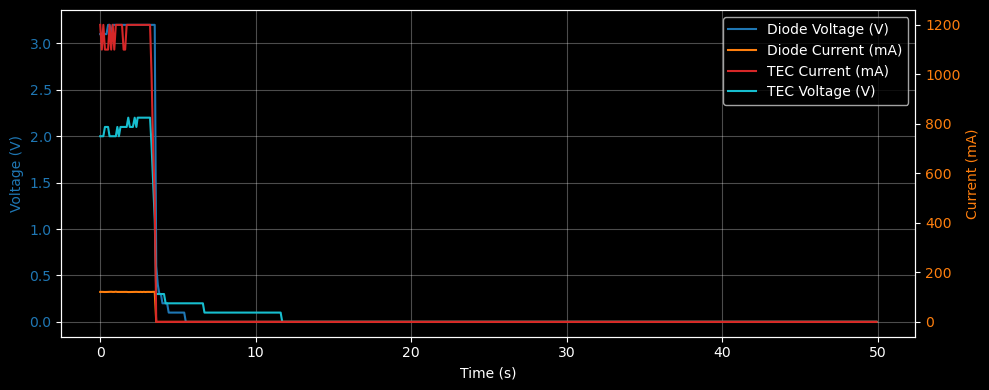

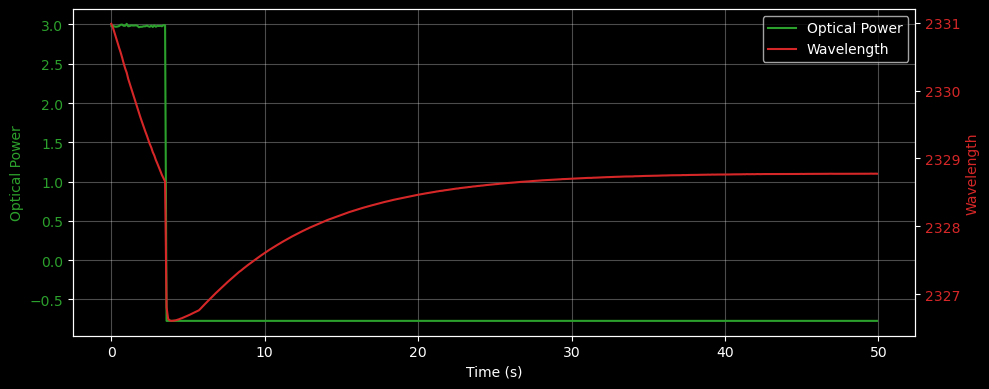

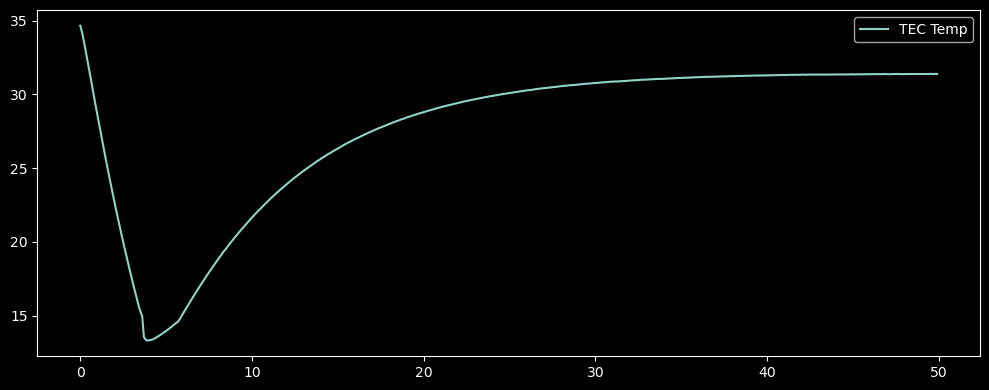

In [48]:
x=data.get_data()
pwr, wave = Laser.compute_power_and_wavelength(lasers['2330'].laser_properties, x['tec_temp_c'], x['diode_current_ma'])


t = x["t_s"]

# --- Plot 1: Electrical (2 y-axes) ---
fig1, ax_v = plt.subplots(figsize=(10, 4))

# Left axis: voltage
l1 = ax_v.plot(t, x["diode_voltage_v"], color="tab:blue", label="Diode Voltage (V)")
l3 = ax_v.plot(t, x["tec_voltage_v"], color="tab:cyan", label="TEC Voltage (V)")
ax_v.set_xlabel("Time (s)")
ax_v.set_ylabel("Voltage (V)", color="tab:blue")
ax_v.tick_params(axis="y", labelcolor="tab:blue")
ax_v.grid(True, alpha=0.3)

# Right axis: current
ax_i = ax_v.twinx()
l2 = ax_i.plot(t, x["diode_current_ma"], color="tab:orange", label="Diode Current (mA)")
l4 = ax_i.plot(t, x["tec_current_a"]*1000, color="tab:red", label="TEC Current (mA)" )
ax_i.set_ylabel("Current (mA)", color="tab:orange")
ax_i.tick_params(axis="y", labelcolor="tab:orange")
# ax_i.set_xlim(0,10)

# Combined legend
lines = l1 + l2 + l4 + l3
labels = [ln.get_label() for ln in lines]
ax_v.legend(lines, labels, loc="best")

fig1.tight_layout()


# --- Plot 2: Optical (2 y-axes) ---
fig2, ax_p = plt.subplots(figsize=(10, 4))

# Left axis: optical power
l3 = ax_p.plot(t, pwr, color="tab:green", label="Optical Power")
ax_p.set_xlabel("Time (s)")
ax_p.set_ylabel("Optical Power", color="tab:green")
ax_p.tick_params(axis="y", labelcolor="tab:green")
ax_p.grid(True, alpha=0.3)

# Right axis: wavelength
ax_w = ax_p.twinx()
l4 = ax_w.plot(t, wave, color="tab:red", label="Wavelength")
ax_w.set_ylabel("Wavelength", color="tab:red")
ax_w.tick_params(axis="y", labelcolor="tab:red")

# Combined legend
lines = l3 + l4
labels = [ln.get_label() for ln in lines]
ax_p.legend(lines, labels, loc="best")

fig2.tight_layout()

plt.subplots(figsize=(10, 4))
plt.plot(t, x['tec_temp_c'], label='TEC Temp')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
lasers['2330'].status(verbose=False)

Laser Properties Name: 2330
Operation started: True
Voltage: 3.2
Current (min-max): 120.00 (0.00-120.00
Current Set Calibration: 100.0
TEC Started: True
 TEC Temperature Setpoint: 26.9
 TEC Temperature: 27.06
 TEC Voltage: 0.3
 TEC Current Limit: 1.2
 TEC Current: 0.2
 TEC Error: False
 TEC Self-heat: False
LD Overcurrent: False
LD Overheat: False


### Make sure it is all off.

In [49]:
for name in names: lasers[name].shutdown()

### Low-level access

In the event that direct device control is needed.

See `ait/maiman_modbus/utils/utils.py` for python constants of register names and `ait/maiman_modbus/config/modbus_config.yaml` for the register addresses.

Look at methods on `ModbusDevice` (`ait/maiman_modbus/device/modbus_device.py`) for functions.


```python
from maiman_modbus.communication import ModbusCommunication
import maiman_modbus.utils as maiman_regs
from maiman_modbus.device.modbus_device_model import ModbusDeviceModel
from maiman_modbus.config import DeviceConfig
from maiman_modbus.device.modbus_device import ModbusDevice

d = ModbusDevice(port=MODBUS_PORT, slave_address=modbus_address)
d.comm.send_command(d.model.get_register(STATE_OF_TEC_COMMAND), MODBUS_START_TEC_COMMAND_VALUE)

print(d.comm.receive_response(d.model.get_register(STATE_OF_TEC_COMMAND)))
```
